# Material Dispersion

___

### In this notebook, we look at how to simulate and define a dispersive media. For simplicity, we shall look at the reflectance and transmittance of a bare crystalline silicon wafer (cSi).

In [ ]:
import meep as mp #imports Meep from your package
import numpy as np #Numerical python package for math operations on matrices and etc
import matplotlib.pyplot as plt #plotting package
from meep.materials import cSi

Using MPI version 4.1, 1 processes


In [ ]:
um_scale = 1
cSi_range = mp.FreqRange(min=um_scale, max=um_scale / 0.4)

# parameters for the first lorentzian resonance
cSi_frq1 = 3.64 / um_scale
cSi_gam1 = 0
cSi_sig1 = 8

# parameters for the second lorentzian resonance
cSi_frq2 = 2.76 / um_scale
cSi_gam2 = 2 * 0.063 / um_scale
cSi_sig2 = 2.85

# parameters for the third lorentzian resonance

cSi_frq3 = 1.73 / um_scale
cSi_gam3 = 2 * 2.5 / um_scale
cSi_sig3 = -0.107

# define the susceptibilities using the lorentzians

cSi_susc = [
    mp.LorentzianSusceptibility(frequency=cSi_frq1, gamma=cSi_gam1, sigma=cSi_sig1),
    mp.LorentzianSusceptibility(frequency=cSi_frq2, gamma=cSi_gam2, sigma=cSi_sig2),
    mp.LorentzianSusceptibility(frequency=cSi_frq3, gamma=cSi_gam3, sigma=cSi_sig3),
]

# Material definition 
Silicon = mp.Medium(epsilon=1.0, E_susceptibilities=cSi_susc, valid_freq_range=cSi_range)

### Test out the material you defined ...

In [92]:
wvl = np.linspace(0.4,1,100)
epsilon_si = []
for i in range(wvl.shape[0]):
    epsilon_si.append(Silicon.epsilon(1/wvl[i])[0,0])

Text(0, 0.5, '$\\kappa$($\\lambda$)')

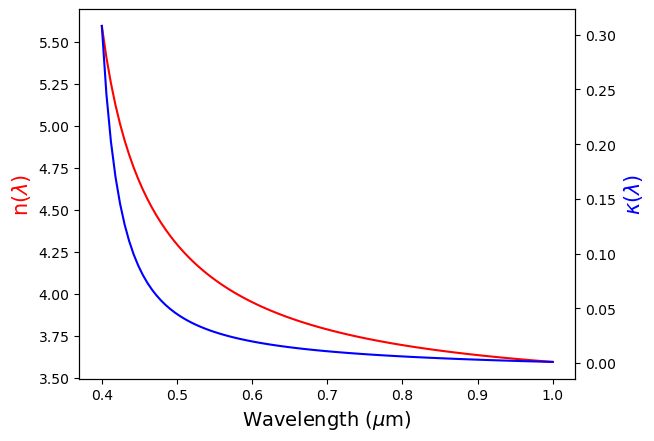

In [106]:
nk = np.array(epsilon_si)**0.5
plt.plot(wvl,np.real(nk),color='red')
plt.ylabel('n($\lambda$)',color='red',fontsize=15)
plt.xlabel('Wavelength ($\mu$m)',fontsize=14)
plt.twinx()
plt.plot(wvl,np.imag(nk),color='blue')
plt.ylabel('$\kappa$($\lambda$)',color='blue',fontsize=15)


Now, we can add this material into our meep geometrical objects.

In [74]:
resolution = 100   # pixels/um
sx,sy=1,5
cell = mp.Vector3(sx,sy,0)
dpml=1
pml_layers = [mp.PML(dpml,direction=mp.Y)]

geometry = [mp.Block(size=mp.Vector3(sx,0.5*sy),center=mp.Vector3(y=-0.5*(0.5*sy)) ,material=cSi)]

wvl_min = 0.4
wvl_max = 1
fmin = 1/wvl_max
fmax = 1/wvl_min
fcen = 0.5 * (fmin+fmax)
df = fmax-fmin       # pulse frequency width
nfreq=200
src = [mp.Source(mp.GaussianSource(fcen, fwidth=df),
                     component=mp.Ez,
                     center=mp.Vector3(y=0.5*sy-dpml),
                     size=mp.Vector3(sx,0))]

k = mp.Vector3(fcen * np.sin(0), -fcen * np.cos(0), 0) 

sim = mp.Simulation(cell_size=cell,
                        #geometry=geometry,
                        k_point=k,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)

ref = mp.FluxRegion(center=mp.Vector3(y=0.5*sy-dpml-0.3),
                         size=mp.Vector3(x=sx))

tra = mp.FluxRegion(center=mp.Vector3(y=-0.5*sy+dpml+0.3),
                         size=mp.Vector3(x=sx))

    # transmitted flux
trans = sim.add_flux(fcen, df, nfreq, tra)
ref = sim.add_flux(fcen, df, nfreq, ref)

<Axes: xlabel='X', ylabel='Y'>

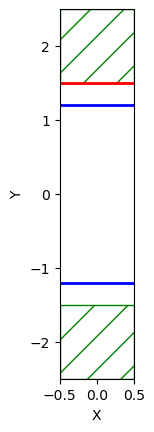

In [59]:
sim.plot2D()

In [75]:
sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mp.Vector3(y=-0.5*sy+dpml+0.3), 1e-3))

-----------
Initializing structure...
time for choose_chunkdivision = 0.000279383 s
Working in 2D dimensions.
Computational cell is 1 x 5 x 0 with resolution 100
time for set_epsilon = 0.104963 s
-----------
Meep: using complex fields.
on time step 6461 (time=32.305), 0.000619187 s/step
field decay(t = 50.005): 0.25073298071556555 / 0.25073298071556555 = 1.0
on time step 11909 (time=59.545), 0.000734304 s/step
on time step 18880 (time=94.4), 0.000573812 s/step
field decay(t = 100.01): 1.54577559376769e-13 / 0.25073298071556555 = 6.165026991487953e-13
run 0 finished at t = 100.01 (20002 timesteps)


In [76]:
straight_refl_data = sim.get_flux_data(ref)
straight_tran_flux = mp.get_fluxes(trans)
inc = mp.get_fluxes(ref)

     block, center = (0,-1.25,0)
          size (1,2.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)


          dielectric constant epsilon diagonal = (1,1,1)
-----------
Initializing structure...
time for choose_chunkdivision = 0.00019401 s
Working in 2D dimensions.
Computational cell is 1 x 5 x 0 with resolution 100
     block, center = (0,-1.25,0)
          size (1,2.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 0.152236 s
lorentzian susceptibility: frequency=1.73, gamma=5
lorentzian susceptibility: frequency=2.76, gamma=0.126
lorentzian susceptibility: frequency=3.64, gamma=0
-----------
Meep: using complex fields.


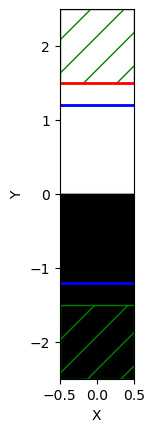

In [77]:
sim.reset_meep()
sim = mp.Simulation(cell_size=cell,
                        geometry=geometry,
                        boundary_layers=pml_layers,
                        sources=src,
                        k_point = k,
                        resolution=resolution)

ref = mp.FluxRegion(center=mp.Vector3(y=0.5*sy-dpml-0.3),
                         size=mp.Vector3(x=sx))

tra = mp.FluxRegion(center=mp.Vector3(y=-0.5*sy+dpml+0.3),
                         size=mp.Vector3(x=sx))

    # transmitted flux
trans = sim.add_flux(fcen, df, nfreq, tra)
ref = sim.add_flux(fcen, df, nfreq, ref)
sim.plot2D()
sim.load_minus_flux_data(ref, straight_refl_data)


In [ ]:
sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, mp.Vector3(y=-0.5*sy+dpml+0.3), 1e-3))

on time step 2044 (time=10.22), 0.00195787 s/step
on time step 4567 (time=22.835), 0.00158577 s/step
on time step 7421 (time=37.105), 0.00140214 s/step
field decay(t = 50.005): 0.010054283059212726 / 0.010054283059212726 = 1.0
on time step 10171 (time=50.855), 0.00145508 s/step
on time step 12949 (time=64.745), 0.00143992 s/step
on time step 15688 (time=78.44), 0.00146054 s/step
on time step 18507 (time=92.535), 0.00141909 s/step
field decay(t = 100.01): 4.840097217943061e-15 / 0.010054283059212726 = 4.813965540295871e-13
run 0 finished at t = 100.01 (20002 timesteps)


Text(0.5, 0, 'Wavelength ($\\mu$m)')

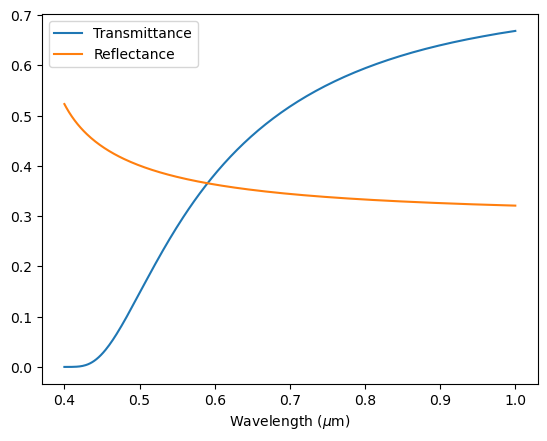

In [80]:
wvl=1/np.array(mp.get_flux_freqs(trans))
plt.plot(wvl,np.array(mp.get_fluxes(trans))/np.array(straight_tran_flux),label='Transmittance')
plt.plot(wvl,-np.array(mp.get_fluxes(ref))/np.array(straight_tran_flux),label='Reflectance')
plt.legend()
plt.xlabel('Wavelength ($\mu$m)')